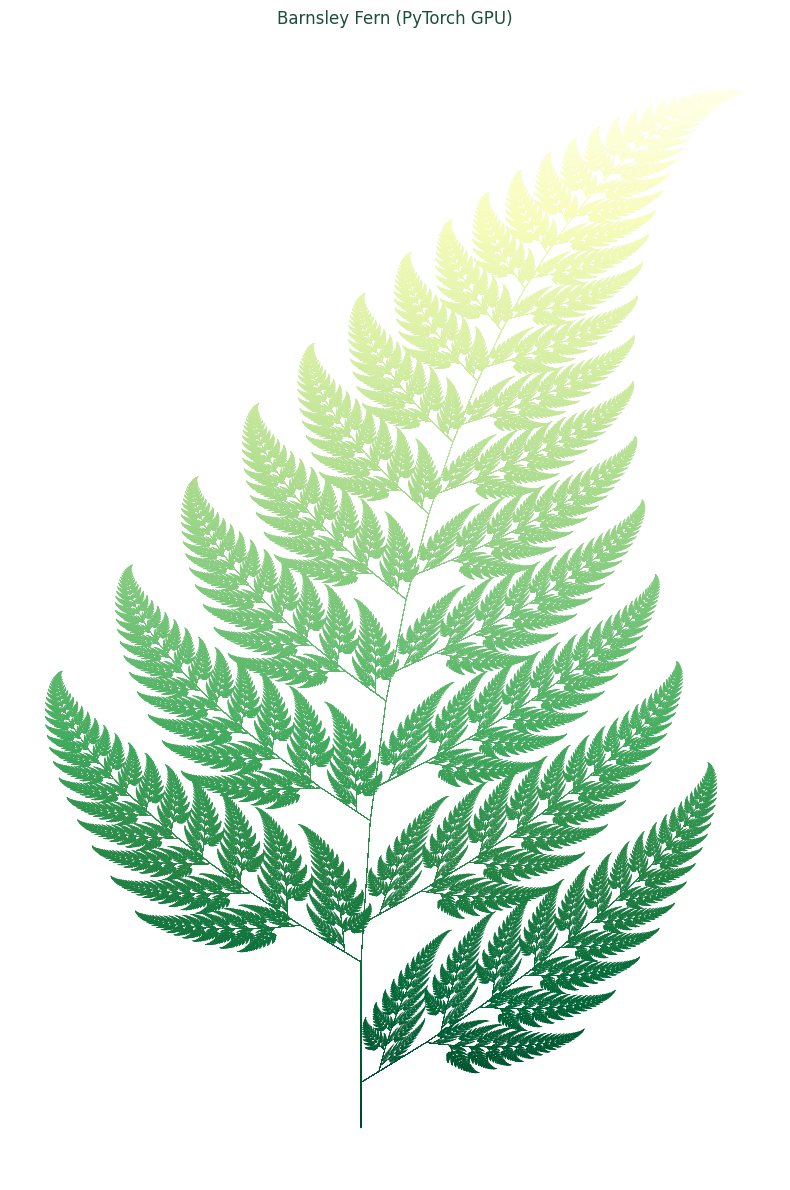

In [4]:
import torch
import numpy as np


def barnsley_fern_gpu_batch(
    num_particles=200000, steps=80, device='cuda' if torch.cuda.is_available() else 'cpu'
):
    # Affine parameters [a, b, c, d, e, f]
    # Shape: (4, 2, 2) for matrix A, (4, 2) for vector B
    A = torch.tensor(
        [
            [[0.00, 0.00], [0.00, 0.16]],  # f1: stem
            [[0.85, 0.04], [-0.04, 0.85]],  # f2: frond
            [[0.20, -0.26], [0.23, 0.22]],  # f3: left leaflet
            [[-0.15, 0.28], [0.26, 0.24]],  # f4: right leaflet
        ],
        dtype=torch.float32,
        device=device,
    )

    B = torch.tensor(
        [[0.00, 0.00], [0.00, 1.60], [0.00, 1.60], [0.00, 0.44]],
        dtype=torch.float32,
        device=device,
    )

    # Adaptive cut probabilities: (0.03, 0.77, 0.13, 0.11) (or standard 0.01, 0.85, 0.07, 0.07)
    probs = torch.tensor([0.03, 0.77, 0.13, 0.11], device=device)

    # State: [num_particles, 2]
    P = torch.zeros(num_particles, 2, device=device)

    # Collector for rendering coordinates after burn-in
    burn_in = 20
    collected_points = []

    for step in range(steps):
        # Sample transform index for every particle simultaneously
        choices = torch.multinomial(probs, num_particles, replacement=True)

        # Select corresponding transform matrices: [num_particles, 2, 2] & [num_particles, 2]
        A_step = A[choices]
        B_step = B[choices]

        # Vectorized affine step: P = (A_step @ P.unsqueeze(-1)).squeeze(-1) + B_step
        P = torch.bmm(A_step, P.unsqueeze(-1)).squeeze(-1) + B_step

        if step >= burn_in:
            collected_points.append(P.clone())

    all_pts = torch.cat(collected_points, dim=0)
    return all_pts[:, 0].cpu().numpy(), all_pts[:, 1].cpu().numpy()


import matplotlib.pyplot as plt
import numpy as np
import torch

x_coords, y_coords = barnsley_fern_gpu_batch()
points = torch.tensor(np.stack([x_coords, y_coords], axis=-1))

pts_np = points.cpu().numpy()

# 1. Set figure background to white
fig = plt.figure(figsize=(8, 12), facecolor="white")
ax = fig.add_subplot(111)
ax.set_facecolor("white")

# 2. Use the reversed colormap 'YlGn_r' (Dark Green -> Light Grass Green)
plt.scatter(
    pts_np[:, 0],
    pts_np[:, 1],
    s=0.05,
    c=pts_np[:, 1],  # Colors based on height (y-coordinate)
    cmap="YlGn_r",  # '_r' reverses the gradient
    edgecolors="none",
)

plt.axis("off")
plt.title(
    "Barnsley Fern (PyTorch GPU)",
    color="#1b4d3e",  # Clean dark forest green title
    fontsize=12,
    pad=10,
)

plt.tight_layout()
plt.show()